In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter as fsf
from plots.mpltoolkit import mpl_loc, fancy_legend, named_colors, load_style_sheet, negative_log
import numpy as np
import vice
import sys
import os
sys.path.insert(0, "..")
from src.utils import subsample_stars, get_velocity_evolution, get_velocity_profile
from src.simulations import neutron_capture_dtds
load_style_sheet("papers")
print(sys.version_info[:])

(3, 12, 3, 'final', 0)


/var/folders/26/nqb98q9x5_q6brmqy4v21dqm0000gp/T/ipykernel_8088/261166665.py:38: RuntimeWarning: divide by zero encountered in log10
  rh = [np.log10(r / mg / 1.0e-9) for r, mg in zip(
/var/folders/26/nqb98q9x5_q6brmqy4v21dqm0000gp/T/ipykernel_8088/261166665.py:42: RuntimeWarning: invalid value encountered in scalar subtract
  rmg = [r - mg for r, mg in zip(rh, mgh)]


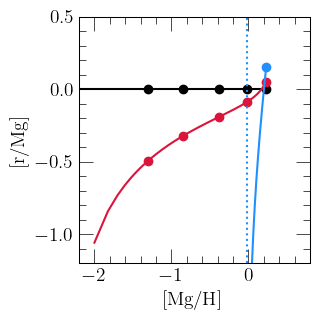

In [14]:
COLORS = {"tl": "black", "pb": "crimson", "bi": "dodgerblue"}
TIMES = [0.1, 0.3, 1, 3, 10]

fig = plt.figure(figsize = (3.3, 3.3))
ax = fig.add_subplot(111)
ax.set_xlabel(r"[Mg/H]")
ax.set_ylabel(r"[r/Mg]")
ax.set_xlim([-2.2, 0.8])
ax.set_ylim([-1.2, 0.5])

vice.yields.ccsne.settings["mg"] = vice.solar_z["mg"]
vice.yields.sneia.settings["mg"] = 0
vice.yields.ccsne.settings["fe"] = 0.35 * vice.solar_z["fe"]
vice.yields.sneia.settings["fe"] = 0.65 * vice.solar_z["fe"]
vice.yields.ccsne.settings["tl"] = 1.0e-9
vice.yields.sneia.settings["tl"] = 0
vice.yields.ccsne.settings["pb"] = 0
vice.yields.sneia.settings["pb"] = 0
vice.yields.ccsne.settings["bi"] = 0
vice.yields.sneia.settings["bi"] = 0

binary_ns = vice.channel(neutron_capture_dtds.binary_ns,
    yields = {"pb": 1.0e-9})
tertiary_ns = vice.channel(neutron_capture_dtds.tertiary_ns,
    yields = {"bi": 1.0e-9})

with vice.singlezone(name = "tmp") as sz:
    sz.func = lambda t: 10 * np.exp(-t / 5)
    sz.mode = "sfr"
    sz.elements = ["fe", "mg", "tl", "pb", "bi"]
    sz.channels = ["ccsne", "sneia", binary_ns, tertiary_ns]
    sz.eta = 0.4
    output = sz.run(np.linspace(0, 10, 1001), overwrite = True, capture = True)
    i = 0
    while output.history["mass(bi)"][i] == 0: i += 1
    ax.axvline(output.history["[mg/h]"][i], c = named_colors()[COLORS["bi"]], linestyle = ":")
    for elem in ["tl", "pb", "bi"]:
        rh = [np.log10(r / mg / 1.0e-9) for r, mg in zip(
            output.history["mass(%s)" % (elem)],
            output.history["mgas"])]
        mgh = output.history["[mg/h]"]
        rmg = [r - mg for r, mg in zip(rh, mgh)]
        ax.plot(mgh, rmg, c = named_colors()[COLORS[elem]])
        for t in TIMES:
            idx = output.history["time"].index(t)
            ax.scatter(mgh[idx], rmg[idx], c = named_colors()[COLORS[elem]])

plt.tight_layout()
plt.show()